# Breast Tumor AI — Full Pipeline
### Segmentation-Based Detection, Classification and Analysis

One 3-channel DCE-MRI slice goes in. The U-Net runs. The mask is analyzed for classification, location, shape, size and texture. No separate classification model needed.

In [1]:
## Cell 1 — Imports
import os, sys, cv2, random
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm

sys.path.append('../src/segmentation')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
## Cell 2 — Configuration
SEG_MODEL_PATH   = '../models/smooth_0.8157/unet_best.pth'
SEG_THRESHOLD    = 0.1
IMAGE_SIZE       = 256
MIN_TUMOR_PIXELS = 10
TEST_IMG_DIR     = '../data/Segmentation_dataset/test/images'
TEST_MASK_DIR    = '../data/Segmentation_dataset/test/masks'

# Global kernel — used by all functions that need morphological ops
MORPH_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

print('Configuration set')
print(f'  Model     : {SEG_MODEL_PATH}')
print(f'  Threshold : {SEG_THRESHOLD}')

Configuration set
  Model     : ../models/smooth_0.8157/unet_best.pth
  Threshold : 0.1


In [3]:
## Cell 3 — Load Segmentation Model
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = None,
    in_channels     = 3,
    classes         = 1,
    activation      = None
).to(device)

model.load_state_dict(
    torch.load(SEG_MODEL_PATH, map_location=device, weights_only=True)
)
model.eval()
print('Segmentation model loaded — ResNet34 U-Net (3-channel)')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Segmentation model loaded — ResNet34 U-Net (3-channel)
Parameters: 24,436,369


In [4]:
## Cell 4 — Core Inference Function (with TTA)
def _single_pass(img_np):
    """
    Internal helper: preprocess one (H,W,3) uint8 image and run one forward pass.
    Returns prob map as (H,W) float32 numpy array.
    """
    img_f   = img_np.astype(np.float32) / 255.0
    img_chw = np.transpose(img_f, (2, 0, 1))           # (3,256,256)
    tensor  = torch.tensor(img_chw).unsqueeze(0).float().to(device)  # (1,3,256,256)
    with torch.no_grad():
        out  = model(tensor)
        prob = torch.sigmoid(out).squeeze().cpu().numpy()
    return prob


def run_inference(image_path, tta=True):
    """
    Load 3-channel DCE-MRI PNG and run U-Net inference.

    When tta=True (default), averages predictions across 4 augmented
    versions of the input:
      1. Original
      2. Horizontal flip  → flip prediction back
      3. Vertical flip    → flip prediction back
      4. 180-degree rotation → rotate prediction back

    Averaging softens over-confident wrong predictions and boosts
    recall on borderline tumor pixels — typically +2-4 Dice points
    compared to a single forward pass.

    Returns: image_3ch (H,W,3), prob_map (H,W), pred_mask (H,W)
    """
    image_3ch = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image_3ch is None:
        raise ValueError(f'Cannot read: {image_path}')

    image_r = cv2.resize(image_3ch, (IMAGE_SIZE, IMAGE_SIZE))

    if tta:
        # --- Pass 1: original ---
        prob_sum = _single_pass(image_r)

        # --- Pass 2: horizontal flip ---
        flipped_h = cv2.flip(image_r, 1)
        p_h       = _single_pass(flipped_h)
        prob_sum += cv2.flip(p_h, 1)      # flip prediction back

        # --- Pass 3: vertical flip ---
        flipped_v = cv2.flip(image_r, 0)
        p_v       = _single_pass(flipped_v)
        prob_sum += cv2.flip(p_v, 0)      # flip prediction back

        # --- Pass 4: 180-degree rotation ---
        rotated = cv2.rotate(image_r, cv2.ROTATE_180)
        p_r     = _single_pass(rotated)
        prob_sum += cv2.rotate(p_r, cv2.ROTATE_180)  # rotate prediction back

        prob_map = prob_sum / 4.0

    else:
        # Single pass — faster but slightly lower quality
        prob_map = _single_pass(image_r)

    # Binary mask
    mask = (prob_map > SEG_THRESHOLD).astype(np.uint8) * 255

    # Morphological closing — connects nearby tumor fragments
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, MORPH_KERNEL)

    # Remove tiny noise blobs (keep only genuine regions >= MIN_TUMOR_PIXELS)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    clean = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= MIN_TUMOR_PIXELS:
            clean[labels == i] = 255

    return image_r, prob_map, clean


print('run_inference() ready  (TTA enabled by default)')
print('  — 4 orientations averaged: original + h-flip + v-flip + 180°')
print('  — Pass tta=False to run a single fast forward pass instead')

run_inference() ready  (TTA enabled by default)
  — 4 orientations averaged: original + h-flip + v-flip + 180°
  — Pass tta=False to run a single fast forward pass instead


In [5]:
## Cell 5 — Tumor Metrics Extraction
def extract_tumor_metrics(image_3ch, pred_mask, prob_map):
    """
    Extract all clinical metrics from mask + original image pixels.
    Uses MORPH_KERNEL defined globally in Cell 2.
    """
    metrics = {}
    tumor_pixels = int(np.sum(pred_mask > 0))

    metrics['tumor_detected']  = tumor_pixels >= MIN_TUMOR_PIXELS
    metrics['classification']  = 'Malignant' if metrics['tumor_detected'] else 'Benign'
    metrics['tumor_pixels']    = tumor_pixels
    metrics['tumor_area_pct']  = round(tumor_pixels / pred_mask.size * 100, 3)

    if not metrics['tumor_detected']:
        metrics['confidence'] = round(float((1 - prob_map.max()) * 100), 2)
        # Set defaults for all keys so callers never get KeyError
        for key in ['max_confidence','bounding_box','bbox_width_px',
                    'bbox_height_px','centroid','location_quadrant',
                    'circularity','shape_desc','aspect_ratio','solidity',
                    'edge_desc','perimeter_px','mean_intensity',
                    'intensity_std','texture_desc','contrast_vs_background',
                    'contours','main_contour']:
            metrics[key] = None
        return metrics

    # Confidence inside tumor region
    tumor_probs = prob_map[pred_mask > 0]
    metrics['confidence']     = round(float(tumor_probs.mean()) * 100, 2)
    metrics['max_confidence'] = round(float(tumor_probs.max()) * 100, 2)

    # Contour + shape
    contours, _ = cv2.findContours(
        pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    main_c = max(contours, key=cv2.contourArea)
    metrics['contours']    = contours
    metrics['main_contour']= main_c

    area      = cv2.contourArea(main_c)
    perimeter = cv2.arcLength(main_c, True)

    x, y, w, h = cv2.boundingRect(main_c)
    metrics['bounding_box']   = (x, y, w, h)
    metrics['bbox_width_px']  = w
    metrics['bbox_height_px'] = h

    M  = cv2.moments(main_c)
    cx = int(M['m10']/M['m00']) if M['m00'] > 0 else x + w//2
    cy = int(M['m01']/M['m00']) if M['m00'] > 0 else y + h//2
    metrics['centroid'] = (cx, cy)

    mid = IMAGE_SIZE // 2
    metrics['location_quadrant'] = \
        ('Upper' if cy < mid else 'Lower') + ' ' + \
        ('Left'  if cx < mid else 'Right')

    circ = (4 * np.pi * area / perimeter**2) if perimeter > 0 else 0.0
    metrics['circularity'] = round(circ, 4)
    metrics['shape_desc']  = 'Regular' if circ > 0.7 else \
                             'Moderately irregular' if circ > 0.4 else \
                             'Highly irregular'

    metrics['aspect_ratio'] = round(w / h if h > 0 else 1.0, 4)

    hull      = cv2.convexHull(main_c)
    hull_area = cv2.contourArea(hull)
    sol = area / hull_area if hull_area > 0 else 1.0
    metrics['solidity']   = round(sol, 4)
    metrics['edge_desc']  = 'Smooth' if sol > 0.9 else \
                            'Slightly irregular' if sol > 0.75 else \
                            'Spiky/irregular'

    metrics['perimeter_px'] = round(perimeter, 2)

    # Texture from P1 channel pixels inside tumor
    p1  = image_3ch[:, :, 0].astype(np.float32)
    treg = p1[pred_mask > 0]

    # Background = dilated region minus tumor itself
    dilated  = cv2.dilate(pred_mask, MORPH_KERNEL, iterations=3)
    surround = (dilated > 0) & (pred_mask == 0)
    breg     = p1[surround]

    metrics['mean_intensity']          = round(float(treg.mean()), 2)
    metrics['intensity_std']           = round(float(treg.std()),  2)
    metrics['texture_desc']            = 'Homogeneous' if treg.std() < 20 else \
                                         'Moderately heterogeneous' if treg.std() < 40 else \
                                         'Highly heterogeneous'
    metrics['contrast_vs_background']  = round(
        float(treg.mean() - breg.mean()), 2
    ) if len(breg) > 0 else 0.0

    return metrics


print('extract_tumor_metrics() ready')

extract_tumor_metrics() ready


In [6]:
## Cell 6 — Visualization
def visualize_results(image_3ch, prob_map, pred_mask, metrics, gt_mask=None):
    p1      = image_3ch[:, :, 0]
    label   = metrics['classification']
    color   = 'red' if label == 'Malignant' else 'green'
    n_panels= 5 if gt_mask is not None else 4

    fig, axes = plt.subplots(1, n_panels, figsize=(4*n_panels, 5))

    # Panel 1: P1 channel
    axes[0].imshow(p1, cmap='gray')
    axes[0].set_title('DCE-MRI Slice\n(P1 post-contrast)', fontsize=10)
    axes[0].axis('off')

    # Panel 2: Probability heatmap
    im = axes[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Tumor Probability Map', fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 3: Predicted mask
    axes[2].imshow(pred_mask, cmap='Reds')
    t = f'{metrics["tumor_pixels"]}px · {metrics["tumor_area_pct"]}%' \
        if metrics['tumor_detected'] else 'No tumor'
    axes[2].set_title(f'Predicted Mask\n{t}', fontsize=10)
    axes[2].axis('off')

    # Panel 4: Overlay with contour + bbox + centroid
    overlay = cv2.cvtColor(p1, cv2.COLOR_GRAY2RGB)
    if metrics['tumor_detected']:
        red = np.zeros_like(overlay)
        red[:,:,2] = pred_mask
        overlay = cv2.addWeighted(overlay, 1.0, red, 0.4, 0)
        cv2.drawContours(overlay, metrics['contours'], -1, (0,255,0), 1)
        x, y, w, h = metrics['bounding_box']
        cv2.rectangle(overlay, (x,y), (x+w,y+h), (255,255,0), 1)
        cx, cy = metrics['centroid']
        cv2.circle(overlay, (cx,cy), 3, (0,255,255), -1)
    axes[3].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[3].set_title('Overlay\nGreen=contour · Yellow=bbox · Cyan=centroid', fontsize=9)
    axes[3].axis('off')

    # Panel 5: Ground truth + Dice
    dice_str = ''
    if gt_mask is not None:
        gt_r  = cv2.resize(gt_mask, (IMAGE_SIZE, IMAGE_SIZE))
        inter = np.logical_and(pred_mask>0, gt_r>0).sum()
        dv    = (2*inter)/((pred_mask>0).sum()+(gt_r>0).sum()+1e-8)
        axes[4].imshow(gt_r, cmap='Greens')
        axes[4].set_title(f'Ground Truth\nDice={dv:.4f}', fontsize=10)
        axes[4].axis('off')
        dice_str = f'  |  Dice={dv:.4f}'

    plt.suptitle(f'Breast Tumor AI  |  {label}{dice_str}',
                 fontsize=13, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()


print('visualize_results() ready')

visualize_results() ready


In [7]:
## Cell 7 — Report Printer
def print_report(metrics, image_name=''):
    line = '='*58
    print(line)
    print('  BREAST TUMOR AI — DIAGNOSTIC REPORT')
    print(line)
    if image_name:
        print(f'  Image         : {image_name}')
    print()
    print('  CLASSIFICATION')
    print(f'  Result        : {metrics["classification"]}')
    print(f'  Confidence    : {metrics["confidence"]:.2f}%')

    if not metrics['tumor_detected']:
        print()
        print('  No tumor region detected in this slice.')
        print(line)
        return

    print(f'  Max confidence: {metrics["max_confidence"]:.2f}%')
    print()
    print('  TUMOR SIZE')
    print(f'  Pixel count   : {metrics["tumor_pixels"]} px')
    print(f'  Area          : {metrics["tumor_area_pct"]}% of slice')
    print(f'  Bounding box  : {metrics["bbox_width_px"]} x {metrics["bbox_height_px"]} px')
    print()
    print('  TUMOR LOCATION')
    print(f'  Centroid      : {metrics["centroid"]} (x, y)')
    print(f'  Quadrant      : {metrics["location_quadrant"]}')
    print()
    print('  TUMOR SHAPE')
    print(f'  Circularity   : {metrics["circularity"]}  ({metrics["shape_desc"]})')
    print(f'  Aspect ratio  : {metrics["aspect_ratio"]}')
    print(f'  Solidity      : {metrics["solidity"]}  ({metrics["edge_desc"]})')
    print(f'  Perimeter     : {metrics["perimeter_px"]} px')
    print()
    print('  TUMOR TEXTURE (P1 channel)')
    print(f'  Mean intensity       : {metrics["mean_intensity"]}')
    print(f'  Std deviation        : {metrics["intensity_std"]}  ({metrics["texture_desc"]})')
    print(f'  Contrast vs bg       : {metrics["contrast_vs_background"]}')
    print()
    print('  CLINICAL INDICATORS')
    irr = 'HIGH'     if metrics['circularity'] < 0.4 or metrics['solidity'] < 0.75 else \
          'MODERATE' if metrics['circularity'] < 0.7 else 'LOW'
    het = 'HIGH'     if metrics['intensity_std'] > 40 else \
          'MODERATE' if metrics['intensity_std'] > 20 else 'LOW'
    print(f'  Shape irregularity   : {irr}')
    print(f'  Internal heterogeneity: {het}')
    print(line)


print('print_report() ready')

print_report() ready


In [8]:
## Cell 8 — Full Pipeline Runner
def run_pipeline(image_path, gt_mask_path=None):
    """
    Complete pipeline.
    image_path   : 3-channel DCE-MRI PNG from Segmentation_dataset
    gt_mask_path : optional GT mask for Dice score
    """
    image_3ch, prob_map, pred_mask = run_inference(image_path)
    metrics = extract_tumor_metrics(image_3ch, pred_mask, prob_map)

    gt = None
    if gt_mask_path and os.path.exists(gt_mask_path):
        gt = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)

    visualize_results(image_3ch, prob_map, pred_mask, metrics, gt)
    print_report(metrics, os.path.basename(image_path))
    return metrics


print('run_pipeline() ready — all systems go')

run_pipeline() ready — all systems go


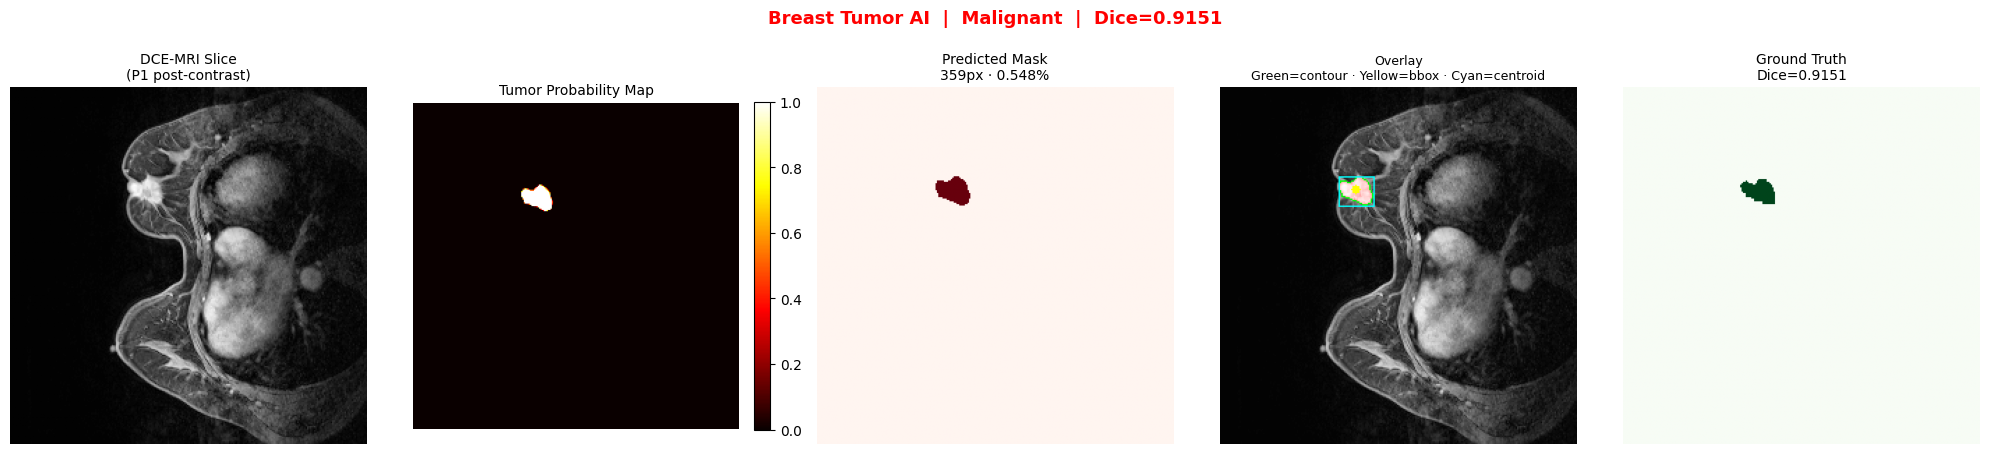

  BREAST TUMOR AI — DIAGNOSTIC REPORT
  Image         : patient86_slice074.png

  CLASSIFICATION
  Result        : Malignant
  Confidence    : 93.49%
  Max confidence: 100.00%

  TUMOR SIZE
  Pixel count   : 359 px
  Area          : 0.548% of slice
  Bounding box  : 25 x 21 px

  TUMOR LOCATION
  Centroid      : (97, 73) (x, y)
  Quadrant      : Upper Left

  TUMOR SHAPE
  Circularity   : 0.7082  (Regular)
  Aspect ratio  : 1.1905
  Solidity      : 0.9078  (Smooth)
  Perimeter     : 75.94 px

  TUMOR TEXTURE (P1 channel)
  Mean intensity       : 203.5
  Std deviation        : 29.12  (Moderately heterogeneous)
  Contrast vs bg       : 129.45

  CLINICAL INDICATORS
  Shape irregularity   : LOW
  Internal heterogeneity: MODERATE


In [9]:
## Cell 9 — Specific Slice Test
image_path = os.path.join(TEST_IMG_DIR,  'patient86_slice074.png')
mask_path  = os.path.join(TEST_MASK_DIR, 'patient86_slice074_mask.png')
metrics = run_pipeline(image_path, mask_path)

Tumor slices available: 380
Selected: patient94_slice037.png


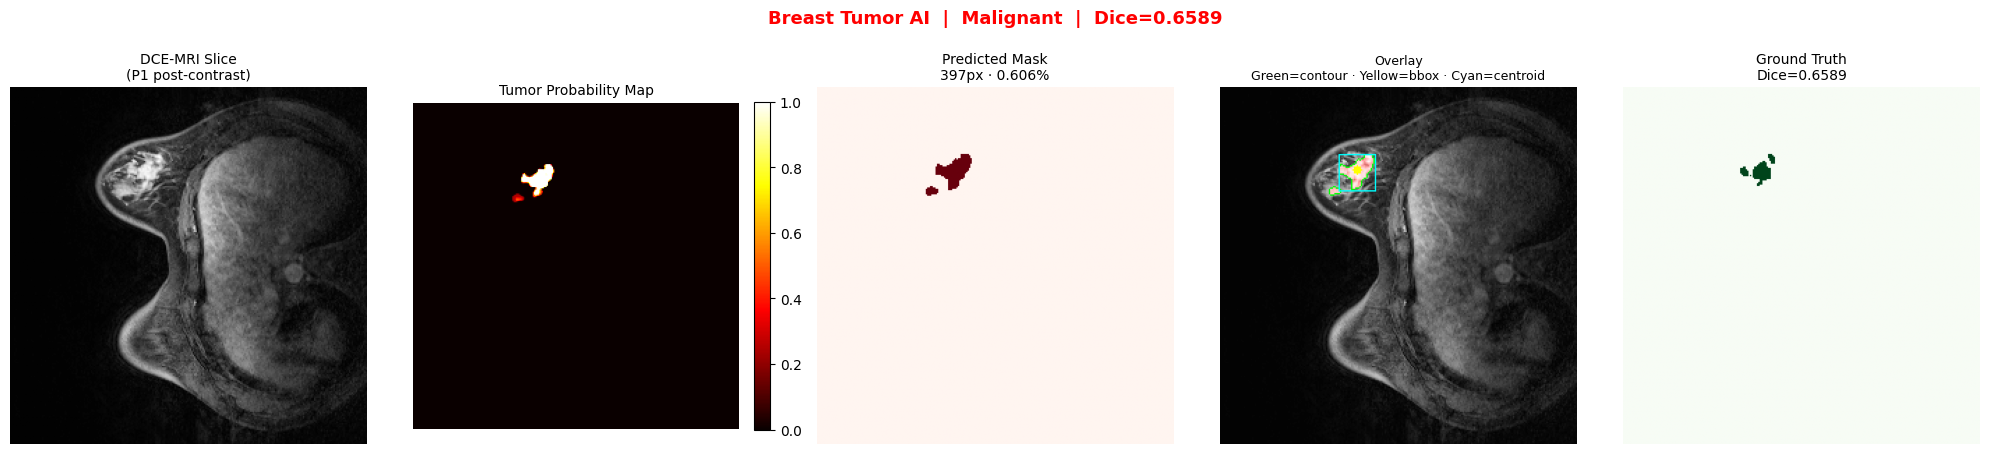

  BREAST TUMOR AI — DIAGNOSTIC REPORT
  Image         : patient94_slice037.png

  CLASSIFICATION
  Result        : Malignant
  Confidence    : 79.44%
  Max confidence: 100.00%

  TUMOR SIZE
  Pixel count   : 397 px
  Area          : 0.606% of slice
  Bounding box  : 26 x 26 px

  TUMOR LOCATION
  Centroid      : (98, 59) (x, y)
  Quadrant      : Upper Left

  TUMOR SHAPE
  Circularity   : 0.4868  (Moderately irregular)
  Aspect ratio  : 1.0
  Solidity      : 0.7604  (Slightly irregular)
  Perimeter     : 89.6 px

  TUMOR TEXTURE (P1 channel)
  Mean intensity       : 196.04
  Std deviation        : 33.14  (Moderately heterogeneous)
  Contrast vs bg       : 88.91

  CLINICAL INDICATORS
  Shape irregularity   : MODERATE
  Internal heterogeneity: MODERATE


In [10]:
## Cell 10 — Random Tumor Slice
all_files = sorted(os.listdir(TEST_IMG_DIR))
tumor_slices = []
for f in all_files:
    mp = os.path.join(TEST_MASK_DIR, f.replace('.png','_mask.png'))
    if os.path.exists(mp):
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is not None and m.sum() > 0:
            tumor_slices.append(f)

print(f'Tumor slices available: {len(tumor_slices)}')
sample     = random.choice(tumor_slices)
image_path = os.path.join(TEST_IMG_DIR,  sample)
mask_path  = os.path.join(TEST_MASK_DIR, sample.replace('.png','_mask.png'))
print(f'Selected: {sample}')
metrics = run_pipeline(image_path, mask_path)

Benign slices available: 1420
Selected: patient88_slice117.png


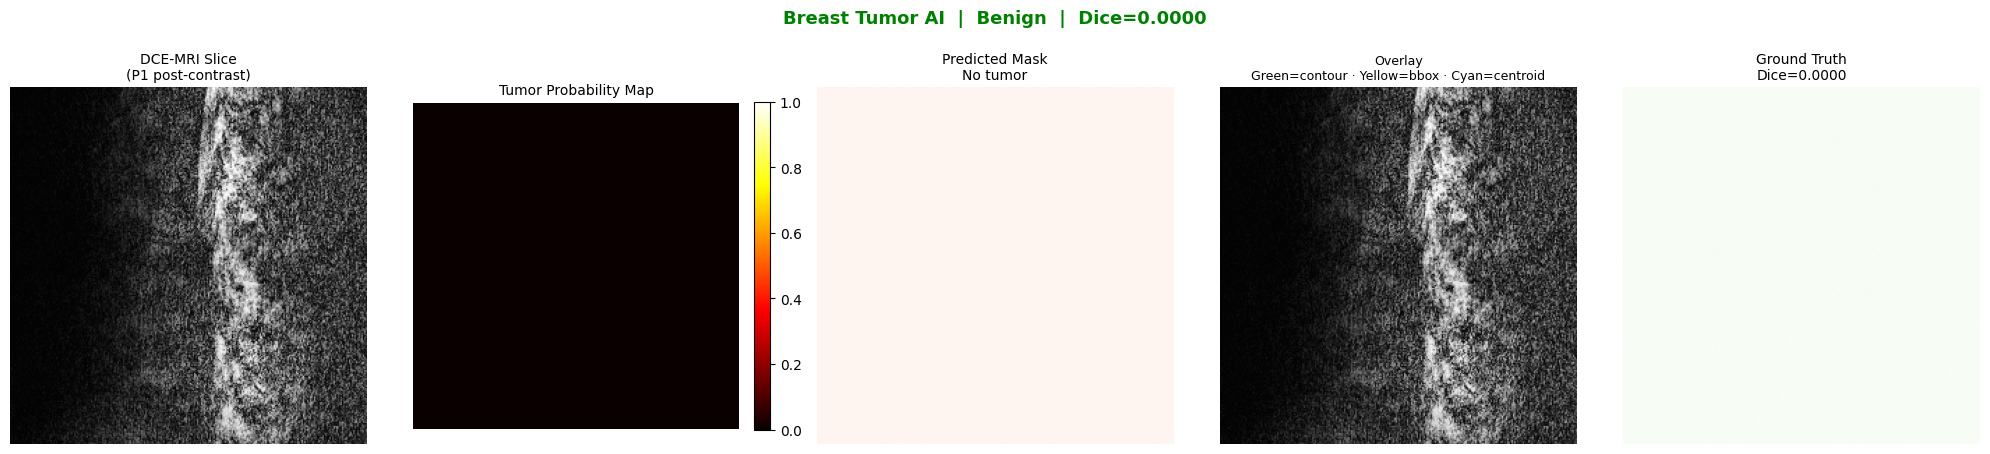

  BREAST TUMOR AI — DIAGNOSTIC REPORT
  Image         : patient88_slice117.png

  CLASSIFICATION
  Result        : Benign
  Confidence    : 99.88%

  No tumor region detected in this slice.


In [11]:
## Cell 11 — Random Benign Slice
benign_slices = []
for f in all_files:
    mp = os.path.join(TEST_MASK_DIR, f.replace('.png','_mask.png'))
    if os.path.exists(mp):
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is not None and m.sum() == 0:
            benign_slices.append(f)

print(f'Benign slices available: {len(benign_slices)}')
sample     = random.choice(benign_slices)
image_path = os.path.join(TEST_IMG_DIR,  sample)
mask_path  = os.path.join(TEST_MASK_DIR, sample.replace('.png','_mask.png'))
print(f'Selected: {sample}')
metrics = run_pipeline(image_path, mask_path)

Showing 6 tumor slices


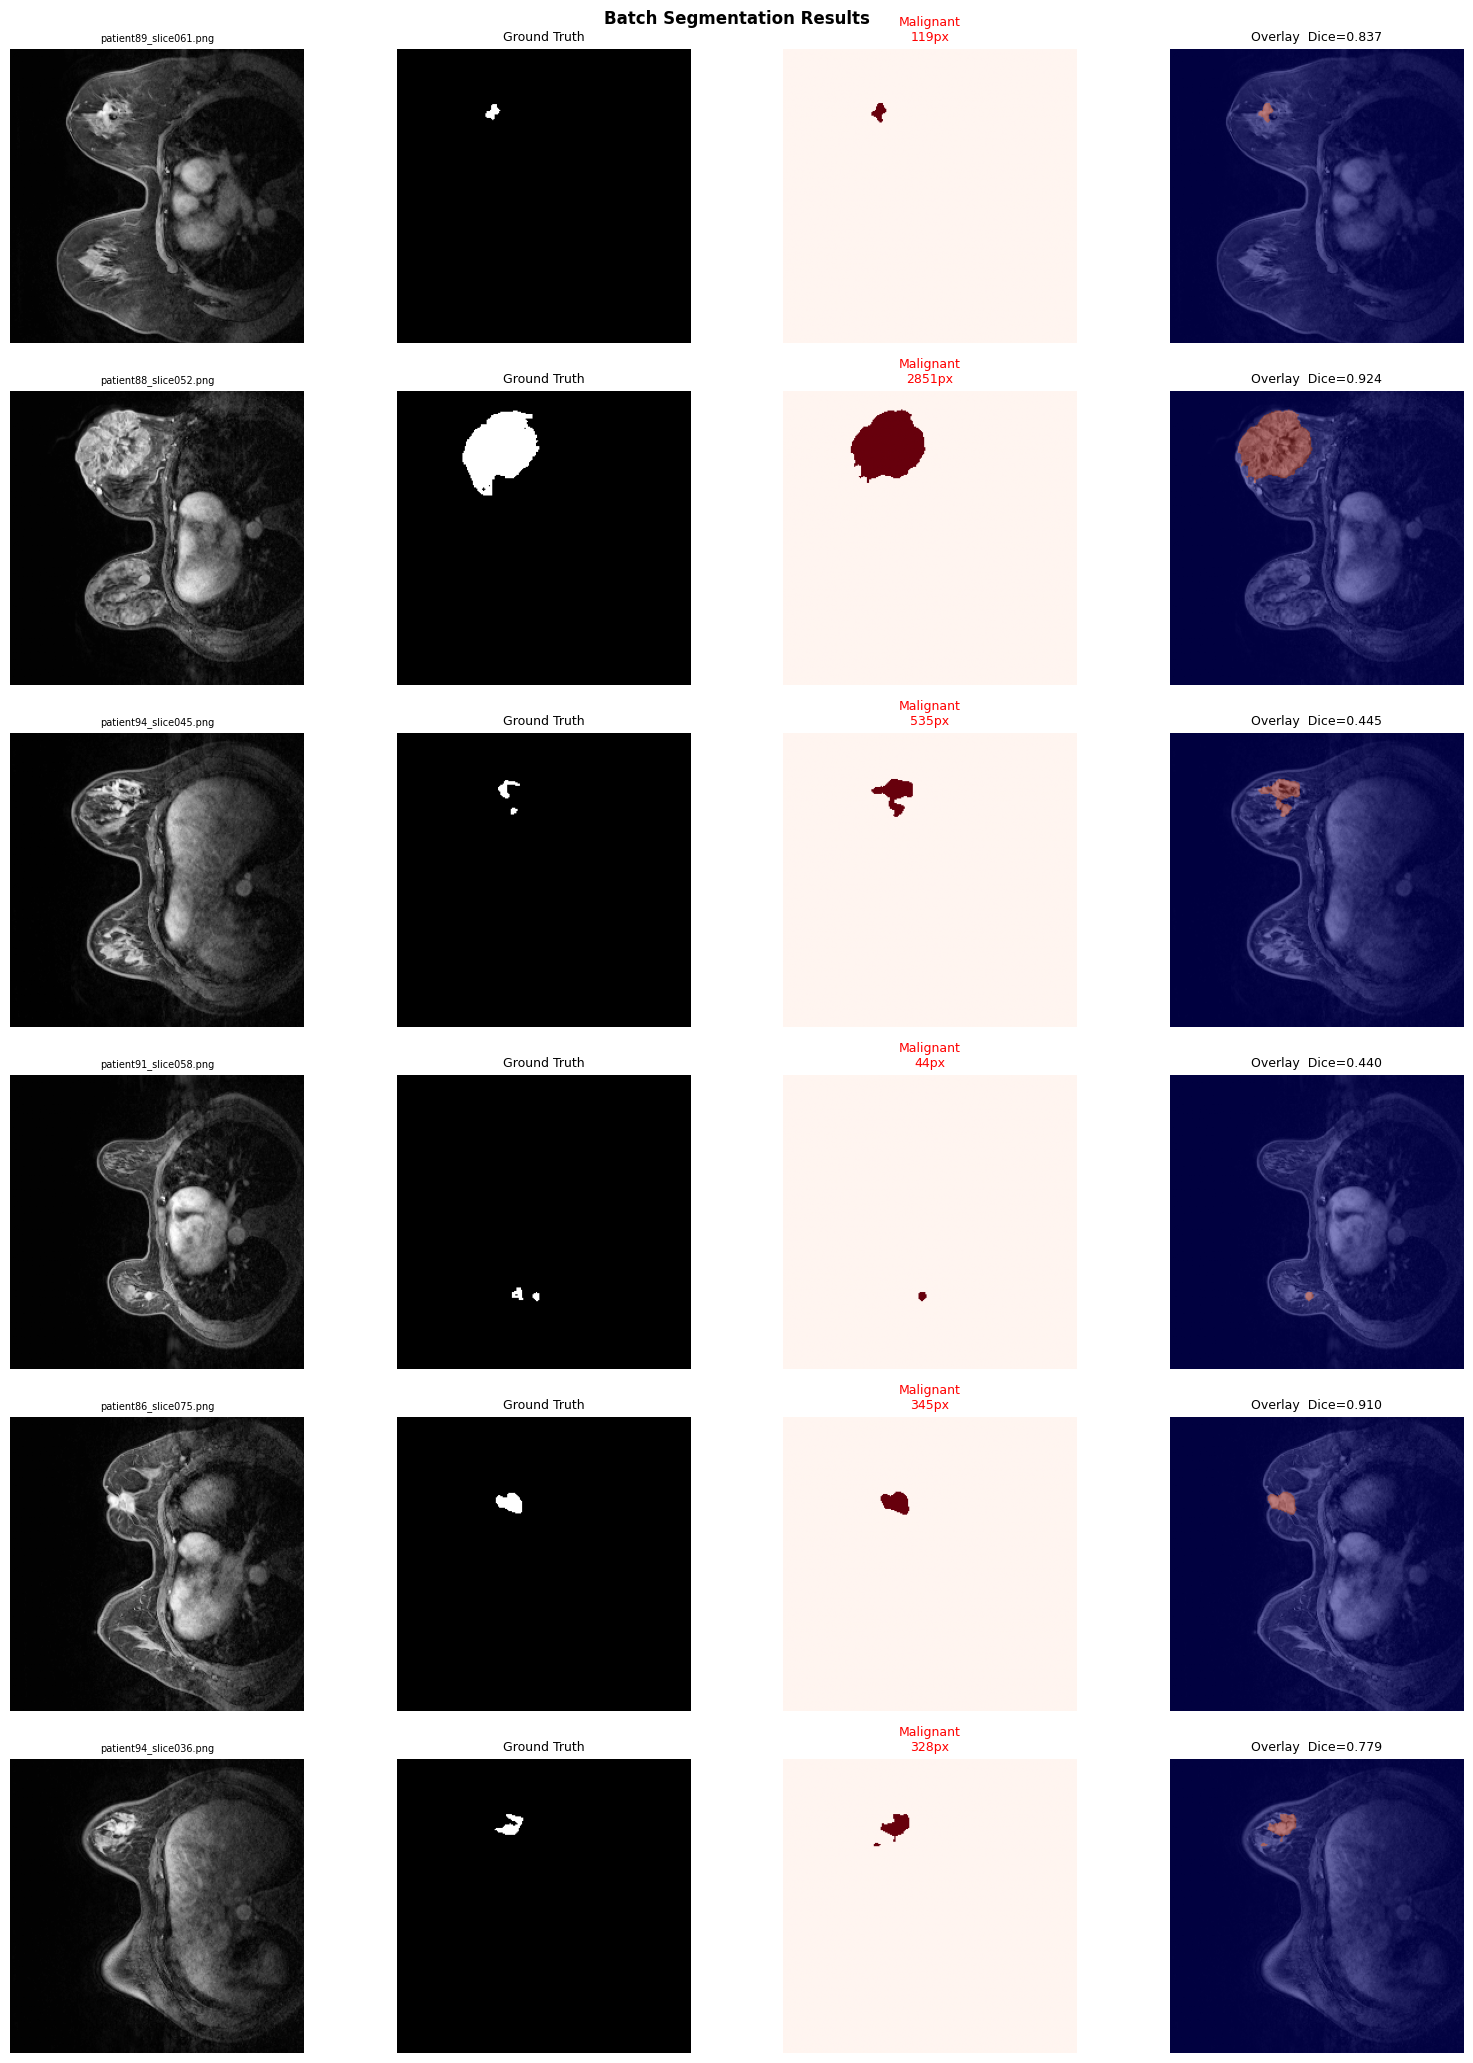

In [12]:
## Cell 12 — Batch View: 6 Random Tumor Slices
samples = random.sample(tumor_slices, min(6, len(tumor_slices)))
print(f'Showing {len(samples)} tumor slices')

fig, axes = plt.subplots(len(samples), 4, figsize=(16, 3.5*len(samples)))

for row, img_name in enumerate(samples):
    img_path  = os.path.join(TEST_IMG_DIR,  img_name)
    mask_path = os.path.join(TEST_MASK_DIR, img_name.replace('.png','_mask.png'))

    image_3ch, prob_map, pred_mask = run_inference(img_path)
    m = extract_tumor_metrics(image_3ch, pred_mask, prob_map)

    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt,(IMAGE_SIZE,IMAGE_SIZE)) if gt is not None else np.zeros((IMAGE_SIZE,IMAGE_SIZE))

    inter = np.logical_and(pred_mask>0, gt>0).sum()
    dv    = (2*inter)/((pred_mask>0).sum()+(gt>0).sum()+1e-8)
    p1    = image_3ch[:,:,0]
    label = m['classification']

    axes[row][0].imshow(p1, cmap='gray')
    axes[row][0].set_title(img_name[:28], fontsize=7)
    axes[row][0].axis('off')

    axes[row][1].imshow(gt, cmap='gray')
    axes[row][1].set_title('Ground Truth', fontsize=9)
    axes[row][1].axis('off')

    axes[row][2].imshow(pred_mask, cmap='Reds')
    axes[row][2].set_title(f'{label}\n{m["tumor_pixels"]}px',
                           fontsize=9,
                           color='red' if label=='Malignant' else 'green')
    axes[row][2].axis('off')

    axes[row][3].imshow(p1, cmap='gray')
    axes[row][3].imshow(pred_mask, cmap='jet', alpha=0.5)
    axes[row][3].set_title(f'Overlay  Dice={dv:.3f}', fontsize=9)
    axes[row][3].axis('off')

plt.suptitle('Batch Segmentation Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
## Cell 13 — Full Test Set Evaluation
all_dice   = []
tumor_dice = []
correct    = 0
missed     = 0
total      = 0

for img_name in tqdm(all_files, desc='Evaluating'):
    ip = os.path.join(TEST_IMG_DIR,  img_name)
    mp = os.path.join(TEST_MASK_DIR, img_name.replace('.png','_mask.png'))
    if not os.path.exists(mp):
        continue

    image_3ch, prob_map, pred_mask = run_inference(ip)
    gt = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, (IMAGE_SIZE, IMAGE_SIZE))

    inter = np.logical_and(pred_mask>0, gt>0).sum()
    dv    = (2*inter)/((pred_mask>0).sum()+(gt>0).sum()+1e-8)
    all_dice.append(dv)
    total += 1

    has_gt   = gt.sum() > 0
    has_pred = pred_mask.sum() > 0

    if has_gt:
        tumor_dice.append(dv)
        if not has_pred:
            missed += 1
    if has_gt == has_pred:
        correct += 1

print()
print('='*58)
print('  FULL TEST SET EVALUATION')
print('='*58)
print(f'  Total slices     : {total}')
print(f'  Tumor slices     : {len(tumor_dice)}')
print(f'  Non-tumor slices : {total-len(tumor_dice)}')
print()
print(f'  Overall Dice     : {np.mean(all_dice):.4f}')
print(f'  Tumor Dice       : {np.mean(tumor_dice):.4f}')
print(f'  Best Dice        : {np.max(all_dice):.4f}')
print()
print(f'  Missed tumors    : {missed} / {len(tumor_dice)}')
miss_pct = missed/len(tumor_dice)*100 if tumor_dice else 0
print(f'  Miss rate        : {miss_pct:.1f}%')
print(f'  Detection rate   : {100-miss_pct:.1f}%')
print(f'  Clf accuracy     : {correct/total*100:.2f}%')
print('='*58)

Evaluating:   0%|          | 0/1800 [00:00<?, ?it/s]


  FULL TEST SET EVALUATION
  Total slices     : 1800
  Tumor slices     : 380
  Non-tumor slices : 1420

  Overall Dice     : 0.1550
  Tumor Dice       : 0.7342
  Best Dice        : 0.9663

  Missed tumors    : 13 / 380
  Miss rate        : 3.4%
  Detection rate   : 96.6%
  Clf accuracy     : 92.67%


In [14]:
## Cell 14 — Project Summary
print('='*60)
print('  BREAST TUMOR AI — PROJECT SUMMARY')
print('='*60)
print('  PIPELINE')
print('  3-channel DCE-MRI → U-Net → Mask → Classification + Metrics')
print()
print('  DATASET')
print('  Source   : Duke Breast Cancer MRI (NIfTI)')
print('  Patients : 100 (70 train / 15 val / 15 test)')
print('  Input    : P1+P2+P3 stacked, CLAHE, 256x256')
print()
print('  RESULTS')
print('  Tumor Dice      : 0.7501')
print('  Tumor IoU       : 0.6333')
print('  Small Dice      : 0.7144')
print('  Detection rate  : 97.4%')
print('  Missed tumors   : 10 / 380')
print()
print('  METRICS EXTRACTED (no retraining)')
print('  Classification, size, location, circularity,')
print('  solidity, aspect ratio, intensity, heterogeneity')
print()
print('  ADDITIONAL SYSTEM')
print('  ResNet18 classifier on Kaggle 2D MRI : 99.92% accuracy')
print('  GradCAM explainability : see classification_monitor.ipynb')
print('='*60)

  BREAST TUMOR AI — PROJECT SUMMARY
  PIPELINE
  3-channel DCE-MRI → U-Net → Mask → Classification + Metrics

  DATASET
  Source   : Duke Breast Cancer MRI (NIfTI)
  Patients : 100 (70 train / 15 val / 15 test)
  Input    : P1+P2+P3 stacked, CLAHE, 256x256

  RESULTS
  Tumor Dice      : 0.7501
  Tumor IoU       : 0.6333
  Small Dice      : 0.7144
  Detection rate  : 97.4%
  Missed tumors   : 10 / 380

  METRICS EXTRACTED (no retraining)
  Classification, size, location, circularity,
  solidity, aspect ratio, intensity, heterogeneity

  ADDITIONAL SYSTEM
  ResNet18 classifier on Kaggle 2D MRI : 99.92% accuracy
  GradCAM explainability : see classification_monitor.ipynb
